In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../class_imbalance/dataset_1039_hiva_agnostic.csv")
df = df.rename(columns={"label": "target"})
df["target"] = (df["target"] == 1).astype(int)
df

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr1608,attr1609,attr1610,attr1611,attr1612,attr1613,attr1614,attr1615,attr1616,target
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4225,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
df['target'].value_counts()

target
0    4080
1     149
Name: count, dtype: int64

In [3]:
train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)
validation = train.sample(frac=0.2, random_state=42)
train = train.drop(validation.index)
X_train = train.drop(columns=["target"]).values.astype(float)
y_train = train["target"].values.astype(float)
X_val = validation.drop(columns=["target"]).values.astype(float)
y_val = validation["target"].values.astype(float)
X_test = test.drop(columns=["target"]).values.astype(float)
y_test = test["target"].values.astype(float)

In [4]:
from logistic_regression import CAGD, F1Threshold, Gaar, LogisticRegression, WeightedErrors

model_default = LogisticRegression(learning_rate=0.01, iterations=1000)
model_gaar = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[Gaar(lambda_=0.01, c_minority=25.0)])
model_focal_loss = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5)])
model_f1_threshold = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[F1Threshold()])
model_g_fl = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0)])
model_g_f1 = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[Gaar(lambda_=0.01, c_minority=25.0), F1Threshold()])
model_fl_f1 = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5), F1Threshold()])
model_g_fl_f1 = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0), F1Threshold()])

model_cagd = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")])
model_g_cagd = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")])
model_fl_cagd = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")])
model_cagd_f1 = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()])
model_g_fl_cagd = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")])
model_g_cagd_f1 = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()])
model_fl_cagd_f1 = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()])
model_g_fl_cagd_f1 = LogisticRegression(learning_rate=0.01, iterations=1000, addons=[WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()])

In [5]:
import time

start = time.perf_counter()
model_default.fit(X_train, y_train)
print(f"Default trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_gaar.fit(X_train, y_train)
print(f"GAAR trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_focal_loss.fit(X_train, y_train)
print(f"Focal loss trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_f1_threshold.fit(X_train, y_train, X_val, y_val)
print(f"F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_g_fl.fit(X_train, y_train)
print(f"GAAR + Focal loss trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_g_f1.fit(X_train, y_train, X_val, y_val)
print(f"GAAR + F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_fl_f1.fit(X_train, y_train, X_val, y_val)
print(f"Focal loss + F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_g_fl_f1.fit(X_train, y_train, X_val, y_val)
print(f"GAAR + Focal loss + F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_cagd.fit(X_train, y_train)
print(f"CAGD trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_g_cagd.fit(X_train, y_train)
print(f"GAAR + CAGD trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_fl_cagd.fit(X_train, y_train)
print(f"Focal loss + CAGD trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_cagd_f1.fit(X_train, y_train, X_val, y_val)
print(f"CAGD + F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_g_fl_cagd.fit(X_train, y_train)
print(f"GAAR + Focal loss + CAGD trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_g_cagd_f1.fit(X_train, y_train, X_val, y_val)
print(f"GAAR + CAGD + F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_fl_cagd_f1.fit(X_train, y_train, X_val, y_val)
print(f"Focal loss + CAGD + F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

start = time.perf_counter()
model_g_fl_cagd_f1.fit(X_train, y_train, X_val, y_val)
print(f"GAAR + Focal loss + CAGD + F1 threshold trained in {time.perf_counter() - start:.4f} seconds")

Default trained in 11.9228 seconds
GAAR trained in 35.6833 seconds
Focal loss trained in 10.7147 seconds
F1 threshold trained in 10.7912 seconds
GAAR + Focal loss trained in 31.8026 seconds
GAAR + F1 threshold trained in 30.2162 seconds
Focal loss + F1 threshold trained in 8.5525 seconds
GAAR + Focal loss + F1 threshold trained in 36.4199 seconds
CAGD trained in 60.3191 seconds
GAAR + CAGD trained in 79.4196 seconds
Focal loss + CAGD trained in 61.7287 seconds
CAGD + F1 threshold trained in 54.3413 seconds
GAAR + Focal loss + CAGD trained in 72.9669 seconds
GAAR + CAGD + F1 threshold trained in 71.8548 seconds
Focal loss + CAGD + F1 threshold trained in 47.7732 seconds
GAAR + Focal loss + CAGD + F1 threshold trained in 70.8757 seconds


In [6]:
y_pred_default = model_default.predict(X_test)
y_pred_gaar = model_gaar.predict(X_test)
y_pred_fl = model_focal_loss.predict(X_test)
y_pred_f1 = model_f1_threshold.predict(X_test)
y_pred_g_fl = model_g_fl.predict(X_test)
y_pred_g_f1 = model_g_f1.predict(X_test)
y_pred_fl_f1 = model_fl_f1.predict(X_test)
y_pred_g_fl_f1 = model_g_fl_f1.predict(X_test)
y_pred_cagd = model_cagd.predict(X_test)
y_pred_g_cagd = model_g_cagd.predict(X_test)
y_pred_fl_cagd = model_fl_cagd.predict(X_test)
y_pred_cagd_f1 = model_cagd_f1.predict(X_test)
y_pred_g_fl_cagd = model_g_fl_cagd.predict(X_test)
y_pred_g_cagd_f1 = model_g_cagd_f1.predict(X_test)
y_pred_fl_cagd_f1 = model_fl_cagd_f1.predict(X_test)
y_pred_g_fl_cagd_f1 = model_g_fl_cagd_f1.predict(X_test)

In [7]:
from metrics import BinaryClassImbalanceMetrics

metrics_default = BinaryClassImbalanceMetrics(y_test, y_pred_default)
metrics_gaar = BinaryClassImbalanceMetrics(y_test, y_pred_gaar)
metrics_fl = BinaryClassImbalanceMetrics(y_test, y_pred_fl)
metrics_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_f1)
metrics_g_fl = BinaryClassImbalanceMetrics(y_test, y_pred_g_fl)
metrics_g_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_g_f1)
metrics_fl_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_fl_f1)
metrics_g_fl_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_g_fl_f1)
metrics_cagd = BinaryClassImbalanceMetrics(y_test, y_pred_cagd)
metrics_g_cagd = BinaryClassImbalanceMetrics(y_test, y_pred_g_cagd)
metrics_fl_cagd = BinaryClassImbalanceMetrics(y_test, y_pred_fl_cagd)
metrics_cagd_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_cagd_f1)
metrics_g_fl_cagd = BinaryClassImbalanceMetrics(y_test, y_pred_g_fl_cagd)
metrics_g_cagd_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_g_cagd_f1)
metrics_fl_cagd_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_fl_cagd_f1)
metrics_g_fl_cagd_f1 = BinaryClassImbalanceMetrics(y_test, y_pred_g_fl_cagd_f1)

In [8]:
print("Default accuracy gain: " + str(metrics_default.accuracy_gain_over_majority()))
print("Gaar accuracy gain: " + str(metrics_gaar.accuracy_gain_over_majority()))
print("Focal loss accuracy gain: " + str(metrics_fl.accuracy_gain_over_majority()))
print("F1 threshold accuracy gain: " + str(metrics_f1.accuracy_gain_over_majority()))
print("GAAR + focal loss accuracy gain: " + str(metrics_g_fl.accuracy_gain_over_majority()))
print("GAAR + F1 threshold accuracy gain: " + str(metrics_g_f1.accuracy_gain_over_majority()))
print("Focal loss + F1 threshold accuracy gain: " + str(metrics_fl_f1.accuracy_gain_over_majority()))
print("GAAR + focal loss + F1 threshold accuracy gain: " + str(metrics_g_fl_f1.accuracy_gain_over_majority()))
print("CAGD accuracy gain: " + str(metrics_cagd.accuracy_gain_over_majority()))
print("GAAR + CAGD accuracy gain: " + str(metrics_g_cagd.accuracy_gain_over_majority()))
print("Focal loss + CAGD accuracy gain: " + str(metrics_fl_cagd.accuracy_gain_over_majority()))
print("CAGD + F1 threshold accuracy gain: " + str(metrics_cagd_f1.accuracy_gain_over_majority()))
print("GAAR + focal loss + CAGD accuracy gain: " + str(metrics_g_fl_cagd.accuracy_gain_over_majority()))
print("GAAR + CAGD + F1 threshold accuracy gain: " + str(metrics_g_cagd_f1.accuracy_gain_over_majority()))
print("Focal loss + CAGD + F1 threshold accuracy gain: " + str(metrics_fl_cagd_f1.accuracy_gain_over_majority()))
print("GAAR + focal loss + CAGD + F1 threshold accuracy gain: " + str(metrics_g_fl_cagd_f1.accuracy_gain_over_majority()))

Default accuracy gain: 0.0011820330969266601
Gaar accuracy gain: -0.024822695035460973
Focal loss accuracy gain: 0.0
F1 threshold accuracy gain: -0.013002364066193817
GAAR + focal loss accuracy gain: -0.03309692671394804
GAAR + F1 threshold accuracy gain: -0.0035460992907802025
Focal loss + F1 threshold accuracy gain: -0.026004728132387744
GAAR + focal loss + F1 threshold accuracy gain: -0.007092198581560294
CAGD accuracy gain: 0.0035460992907800915
GAAR + CAGD accuracy gain: -0.011820330969267157
Focal loss + CAGD accuracy gain: 0.0023640661938534313
CAGD + F1 threshold accuracy gain: -0.0023640661938534313
GAAR + focal loss + CAGD accuracy gain: -0.02009456264775411
GAAR + CAGD + F1 threshold accuracy gain: -0.0035460992907802025
Focal loss + CAGD + F1 threshold accuracy gain: -0.0011820330969267712
GAAR + focal loss + CAGD + F1 threshold accuracy gain: -0.0023640661938534313


In [9]:
print("Default balanced accuracy: " + str(metrics_default.balanced_accuracy()))
print("Gaar balanced accuracy: " + str(metrics_gaar.balanced_accuracy()))
print("Focal loss balanced accuracy: " + str(metrics_fl.balanced_accuracy()))
print("F1 threshold balanced accuracy: " + str(metrics_f1.balanced_accuracy()))
print("GAAR + focal loss balanced accuracy: " + str(metrics_g_fl.balanced_accuracy()))
print("GAAR + F1 threshold balanced accuracy: " + str(metrics_g_f1.balanced_accuracy()))
print("Focal loss + F1 threshold balanced accuracy: " + str(metrics_fl_f1.balanced_accuracy()))
print("GAAR + focal loss + F1 threshold balanced accuracy: " + str(metrics_g_fl_f1.balanced_accuracy()))
print("CAGD balanced accuracy: " + str(metrics_cagd.balanced_accuracy()))
print("GAAR + CAGD balanced accuracy: " + str(metrics_g_cagd.balanced_accuracy()))
print("Focal loss + CAGD balanced accuracy: " + str(metrics_fl_cagd.balanced_accuracy()))
print("CAGD + F1 threshold balanced accuracy: " + str(metrics_cagd_f1.balanced_accuracy()))
print("GAAR + focal loss + CAGD balanced accuracy: " + str(metrics_g_fl_cagd.balanced_accuracy()))
print("GAAR + CAGD + F1 threshold balanced accuracy: " + str(metrics_g_cagd_f1.balanced_accuracy()))
print("Focal loss + CAGD + F1 threshold balanced accuracy: " + str(metrics_fl_cagd_f1.balanced_accuracy()))
print("GAAR + focal loss + CAGD + F1 threshold balanced accuracy: " + str(metrics_g_fl_cagd_f1.balanced_accuracy()))

Default balanced accuracy: 0.5172413793103449
Gaar balanced accuracy: 0.6700713290845397
Focal loss balanced accuracy: 0.5
F1 threshold balanced accuracy: 0.5764149748870975
GAAR + focal loss balanced accuracy: 0.6990461317688769
GAAR + F1 threshold balanced accuracy: 0.614569704132022
Focal loss + F1 threshold balanced accuracy: 0.5364242603300553
GAAR + focal loss + F1 threshold balanced accuracy: 0.6293631030262103
CAGD balanced accuracy: 0.6016122905499515
GAAR + CAGD balanced accuracy: 0.6102857384037479
Focal loss + CAGD balanced accuracy: 0.5677415270333009
CAGD + F1 threshold balanced accuracy: 0.5985523150297556
GAAR + focal loss + CAGD balanced accuracy: 0.6226311568817795
GAAR + CAGD + F1 threshold balanced accuracy: 0.5979403199257165
Focal loss + CAGD + F1 threshold balanced accuracy: 0.6157936943401005
GAAR + focal loss + CAGD + F1 threshold balanced accuracy: 0.5985523150297556


In [10]:
print("Default confusion matrix: " + str(metrics_default.pretty_print_confusion_matrix()))
print("Gaar confusion matrix: " + str(metrics_gaar.pretty_print_confusion_matrix()))
print("Focal loss confusion matrix: " + str(metrics_fl.pretty_print_confusion_matrix()))
print("F1 threshold confusion matrix: " + str(metrics_f1.pretty_print_confusion_matrix()))
print("GAAR + focal loss confusion matrix: " + str(metrics_g_fl.pretty_print_confusion_matrix()))
print("GAAR + F1 threshold confusion matrix: " + str(metrics_g_f1.pretty_print_confusion_matrix()))
print("Focal loss + F1 threshold confusion matrix: " + str(metrics_fl_f1.pretty_print_confusion_matrix()))
print("GAAR + focal loss + F1 threshold confusion matrix: " + str(metrics_g_fl_f1.pretty_print_confusion_matrix()))
print("CAGD confusion matrix: " + str(metrics_cagd.pretty_print_confusion_matrix()))
print("GAAR + CAGD confusion matrix: " + str(metrics_g_cagd.pretty_print_confusion_matrix()))
print("Focal loss + CAGD confusion matrix: " + str(metrics_fl_cagd.pretty_print_confusion_matrix()))
print("CAGD + F1 threshold confusion matrix: " + str(metrics_cagd_f1.pretty_print_confusion_matrix()))
print("GAAR + focal loss + CAGD confusion matrix: " + str(metrics_g_fl_cagd.pretty_print_confusion_matrix()))
print("GAAR + CAGD + F1 threshold confusion matrix: " + str(metrics_g_cagd_f1.pretty_print_confusion_matrix()))
print("Focal loss + CAGD + F1 threshold confusion matrix: " + str(metrics_fl_cagd_f1.pretty_print_confusion_matrix()))
print("GAAR + focal loss + CAGD + F1 threshold confusion matrix: " + str(metrics_g_fl_cagd_f1.pretty_print_confusion_matrix()))

Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     817       0
True 1      28       1
Default confusion matrix: Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     817       0
True 1      28       1
Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     785      32
True 1      18      11
Gaar confusion matrix: Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     785      32
True 1      18      11
Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     817       0
True 1      29       0
Focal loss confusion matrix: Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     817       0
True 1      29       0
Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     801      16
True 1      24       5
F1 threshold confusion matrix: Confusion matrix [[TN, FP], [FN, TP]]
        Pred 0  Pred 1
True 0     801      16
True 1      24       5
Confusion matrix [[TN, FP], [FN, TP

In [11]:
print("Default: ")
print(metrics_default.summary())
print("Gaar: ")
print(metrics_gaar.summary())
print("Focal loss: ")
print(metrics_fl.summary())
print("F1 threshold: ")
print(metrics_f1.summary())
print("GAAR + focal loss: ")
print(metrics_g_fl.summary())
print("GAAR + F1 threshold: ")
print(metrics_g_f1.summary())
print("Focal loss + F1 threshold: ")
print(metrics_fl_f1.summary())
print("GAAR + focal loss + F1 threshold: ")
print(metrics_g_fl_f1.summary())
print("CAGD: ")
print(metrics_cagd.summary())
print("GAAR + CAGD: ")
print(metrics_g_cagd.summary())
print("Focal loss + CAGD: ")
print(metrics_fl_cagd.summary())
print("CAGD + F1 threshold: ")
print(metrics_cagd_f1.summary())
print("GAAR + focal loss + CAGD: ")
print(metrics_g_fl_cagd.summary())
print("GAAR + CAGD + F1 threshold: ")
print(metrics_g_cagd_f1.summary())
print("Focal loss + CAGD + F1 threshold: ")
print(metrics_fl_cagd_f1.summary())
print("GAAR + focal loss + CAGD + F1 threshold: ")
print(metrics_g_fl_cagd_f1.summary())

Default: 
{'accuracy': 0.966903073286052, 'majority_baseline_accuracy': 0.9657210401891253, 'accuracy_gain_over_majority': 0.0011820330969266601, 'balanced_accuracy': 0.5172413793103449, 'minority_recall': 0.034482758620689655, 'minority_error_rate': 0.9655172413793104}
Gaar: 
{'accuracy': 0.9408983451536643, 'majority_baseline_accuracy': 0.9657210401891253, 'accuracy_gain_over_majority': -0.024822695035460973, 'balanced_accuracy': 0.6700713290845397, 'minority_recall': 0.3793103448275862, 'minority_error_rate': 0.6206896551724138}
Focal loss: 
{'accuracy': 0.9657210401891253, 'majority_baseline_accuracy': 0.9657210401891253, 'accuracy_gain_over_majority': 0.0, 'balanced_accuracy': 0.5, 'minority_recall': 0.0, 'minority_error_rate': 1.0}
F1 threshold: 
{'accuracy': 0.9527186761229315, 'majority_baseline_accuracy': 0.9657210401891253, 'accuracy_gain_over_majority': -0.013002364066193817, 'balanced_accuracy': 0.5764149748870975, 'minority_recall': 0.1724137931034483, 'minority_error_rate

,Accuracy,Majority baseline,Gain over majority,Balanced accuracy,Minority recall,Minority error rate
Default,0.967,0.966,0.001,0.517,0.034,0.966
GAAR,0.941,0.966,-0.025,0.670,0.379,0.621
Focal loss,0.966,0.966,0.000,0.500,0.000,1.000
F1 threshold,0.953,0.966,-0.013,0.576,0.172,0.828
GAAR + focal loss,0.933,0.966,-0.033,0.699,0.448,0.552
GAAR + F1 threshold,0.962,0.966,-0.004,0.615,0.241,0.759
Focal loss + F1 threshold,0.940,0.966,-0.026,0.536,0.103,0.897
GAAR + focal loss + F1 threshold,0.959,0.966,-0.007,0.629,0.276,0.724
CAGD,0.969,0.966,0.004,0.602,0.207,0.793
GAAR + CAGD,0.954,0.966,-0.012,0.610,0.241,0.759


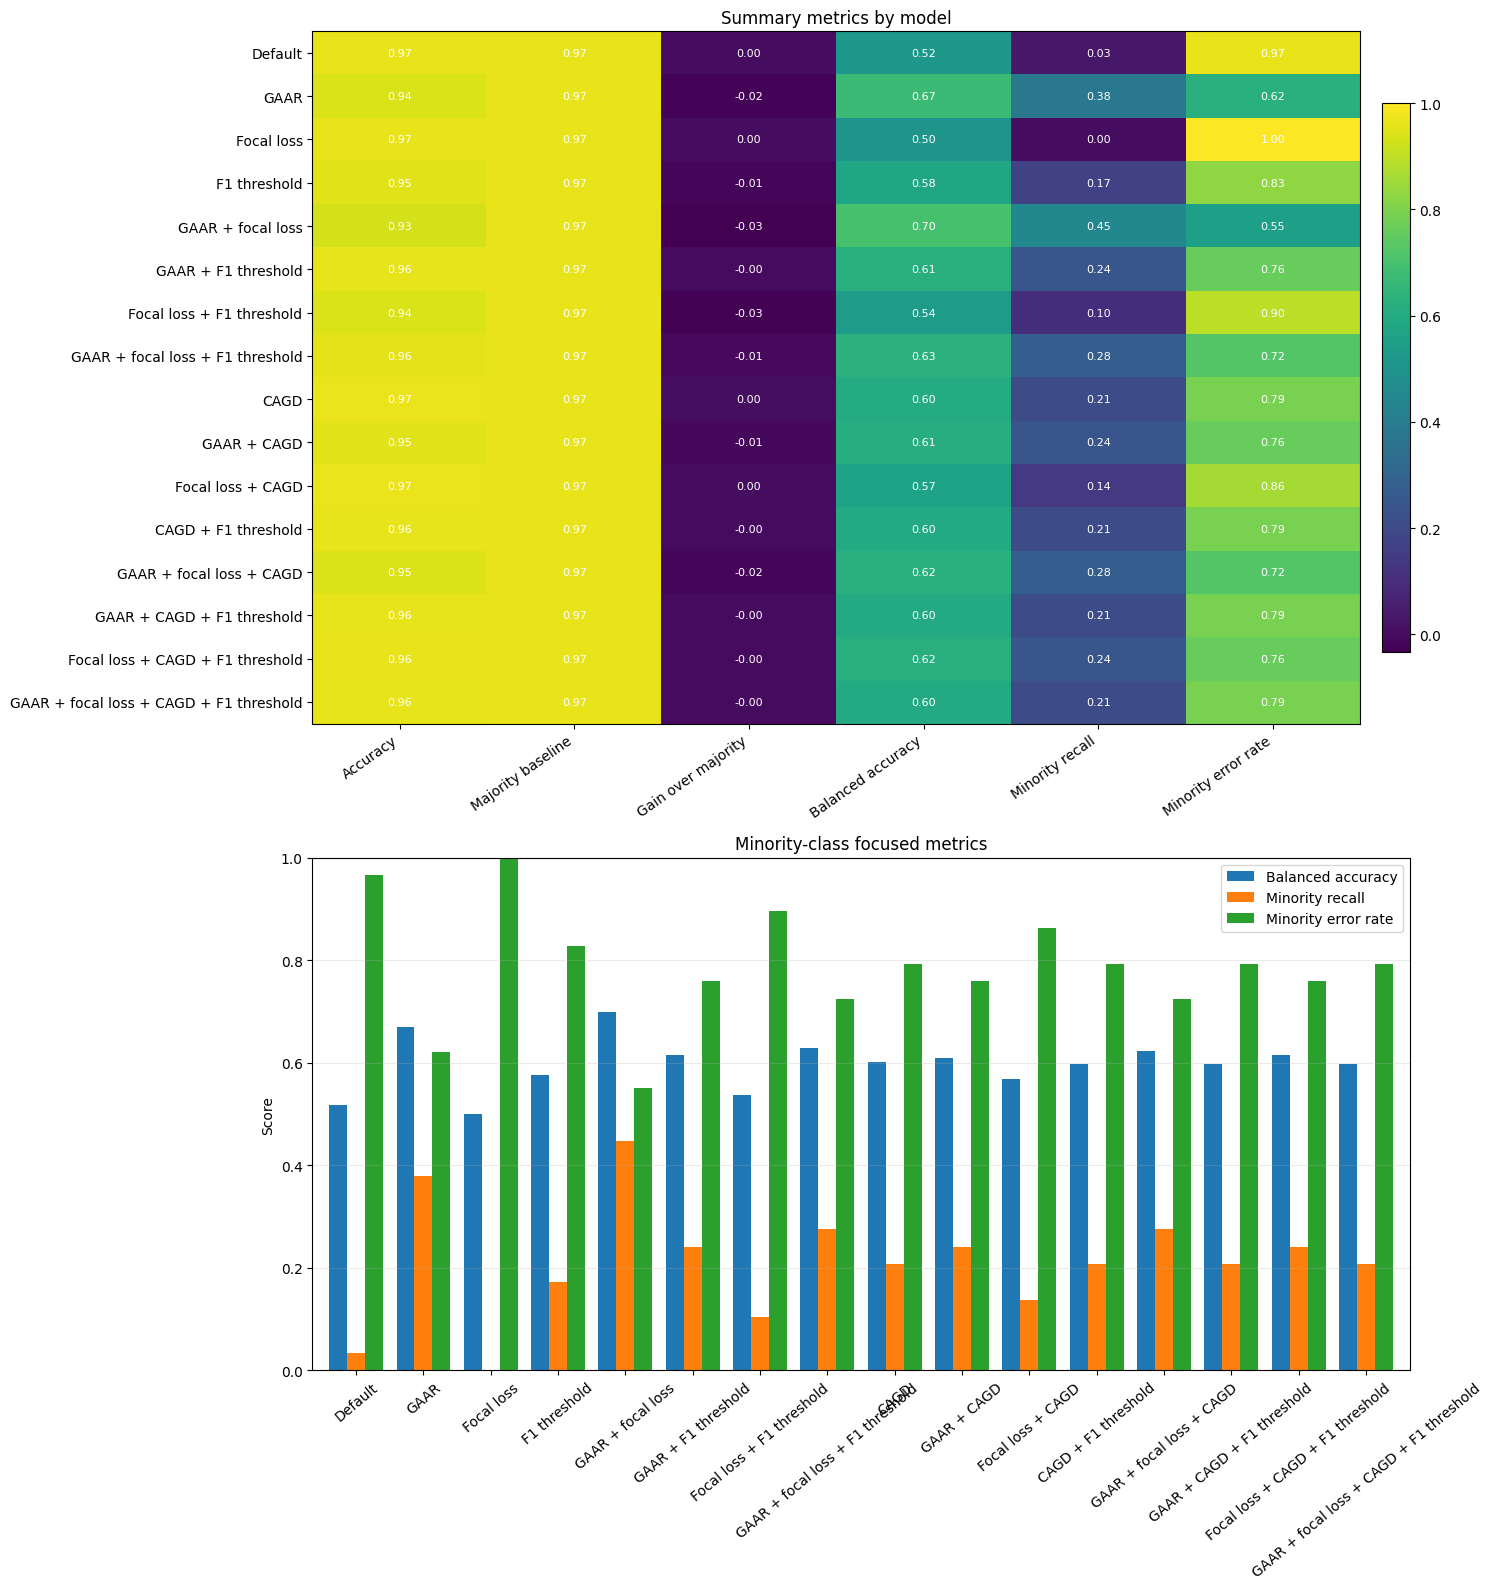

In [12]:
import matplotlib.pyplot as plt

summary_df = pd.DataFrame(
    {
        "Default": metrics_default.summary(),
        "GAAR": metrics_gaar.summary(),
        "Focal loss": metrics_fl.summary(),
        "F1 threshold": metrics_f1.summary(),
        "GAAR + focal loss": metrics_g_fl.summary(),
        "GAAR + F1 threshold": metrics_g_f1.summary(),
        "Focal loss + F1 threshold": metrics_fl_f1.summary(),
        "GAAR + focal loss + F1 threshold": metrics_g_fl_f1.summary(),
        "CAGD": metrics_cagd.summary(),
        "GAAR + CAGD": metrics_g_cagd.summary(),
        "Focal loss + CAGD": metrics_fl_cagd.summary(),
        "CAGD + F1 threshold": metrics_cagd_f1.summary(),
        "GAAR + focal loss + CAGD": metrics_g_fl_cagd.summary(),
        "GAAR + CAGD + F1 threshold": metrics_g_cagd_f1.summary(),
        "Focal loss + CAGD + F1 threshold": metrics_fl_cagd_f1.summary(),
        "GAAR + focal loss + CAGD + F1 threshold": metrics_g_fl_cagd_f1.summary(),
    }
).T

metric_labels = {
    "accuracy": "Accuracy",
    "majority_baseline_accuracy": "Majority baseline",
    "accuracy_gain_over_majority": "Gain over majority",
    "balanced_accuracy": "Balanced accuracy",
    "minority_recall": "Minority recall",
    "minority_error_rate": "Minority error rate",
}

summary_plot_df = summary_df.rename(columns=metric_labels)
display(summary_plot_df.round(3))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 16),
    gridspec_kw={"height_ratios": [1.35, 1]},
)

heatmap_values = summary_plot_df.to_numpy()
image = axes[0].imshow(heatmap_values, aspect="auto", cmap="viridis")
axes[0].set_title("Summary metrics by model")
axes[0].set_xticks(np.arange(len(summary_plot_df.columns)))
axes[0].set_xticklabels(summary_plot_df.columns, rotation=35, ha="right")
axes[0].set_yticks(np.arange(len(summary_plot_df.index)))
axes[0].set_yticklabels(summary_plot_df.index)

for row in range(heatmap_values.shape[0]):
    for column in range(heatmap_values.shape[1]):
        axes[0].text(
            column,
            row,
            f"{heatmap_values[row, column]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
        )

fig.colorbar(image, ax=axes[0], fraction=0.025, pad=0.02)

focus_metrics = [
    "Balanced accuracy",
    "Minority recall",
    "Minority error rate",
]
summary_plot_df[focus_metrics].plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("Minority-class focused metrics")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend(loc="upper right")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()